<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting QFT2002 simulation...
Initial energy: 2.542516e+03
Step     0 /  4000 | E = 3.115922e+02 | max|phi| = 6.585e-17
Step   200 /  4000 | E = 3.113430e+02 | max|phi| = 5.113e-17
Step   400 /  4000 | E = 3.110940e+02 | max|phi| = 2.412e-17
Step   600 /  4000 | E = 3.108452e+02 | max|phi| = 2.759e-17
Step   800 /  4000 | E = 3.105967e+02 | max|phi| = 1.769e-17
Step  1000 /  4000 | E = 3.103483e+02 | max|phi| = 2.135e-17
Step  1200 /  4000 | E = 3.101001e+02 | max|phi| = 2.245e-17
Step  1400 /  4000 | E = 3.098521e+02 | max|phi| = 1.979e-17
Step  1600 /  4000 | E = 3.096043e+02 | max|phi| = 1.803e-17
Step  1800 /  4000 | E = 3.093568e+02 | max|phi| = 1.956e-17
Step  2000 /  4000 | E = 3.091094e+02 | max|phi| = 1.864e-17
Step  2200 /  4000 | E = 3.088622e+02 | max|phi| = 1.752e-17
Step  2400 /  4000 | E = 3.086152e+02 | max|phi| = 1.889e-17
Step  2600 /  4000 | E = 3.083684e+02 | max|phi| = 2.241e-17
Step  2800 /  4000 | E = 3.081218e+02 | max|phi| = 2.013e-17
Step  3000 /  4000 | E = 

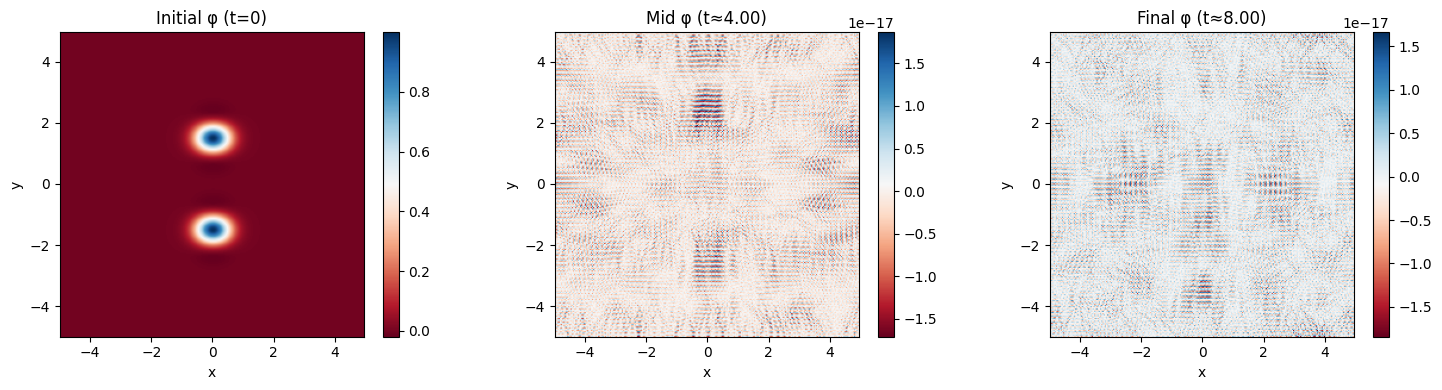

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# QFT2002: 2D Field Interference Test
# =========================
# - 2D lattice
# - Two Gaussian bundles
# - Opposite momenta
# - Harmonic filter centered at N = 100
# - Clean regime (no noise)
# - Diagnostics + optional snapshots

# -------------------------
# Simulation parameters
# -------------------------
Nx, Ny = 256, 256          # grid size
Lx, Ly = 10.0, 10.0        # physical size (arbitrary units)
dx, dy = Lx / Nx, Ly / Ny

dt = 0.002                 # time step
n_steps = 4000             # total steps
output_every = 200         # diagnostics interval

c2 = 1.0                   # wave speed squared
damping = 0.001            # small damping for stability

# Harmonic filter parameters (N = 100 band)
k0 = 100.0                 # target harmonic index (in grid units)
dk = 5.0                   # band half-width

# -------------------------
# Coordinate grids
# -------------------------
x = (np.arange(Nx) - Nx//2) * dx
y = (np.arange(Ny) - Ny//2) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

# -------------------------
# Initial conditions: two Gaussian bundles
# -------------------------
# Bundle parameters
sigma = 0.4
amp = 1.0

# Positions
x1, y1 = -1.5, 0.0
x2, y2 =  1.5, 0.0

# Momenta (opposite directions along x)
p1x, p1y =  2.0, 0.0
p2x, p2y = -2.0, 0.0

def gaussian_packet(x0, y0, px, py):
    r2 = (X - x0)**2 + (Y - y0)**2
    phase = px * (X - x0) + py * (Y - y0)
    return amp * np.exp(-r2 / (2 * sigma**2)) * np.cos(phase)

def gaussian_packet_vel(x0, y0, px, py):
    # Time derivative of cos(phase) ~ -ω sin(phase); approximate ω ≈ |p|
    r2 = (X - x0)**2 + (Y - y0)**2
    phase = px * (X - x0) + py * (Y - y0)
    omega = np.sqrt(px**2 + py**2 + 1e-12)
    return -amp * omega * np.exp(-r2 / (2 * sigma**2)) * np.sin(phase)

phi = (gaussian_packet(x1, y1, p1x, p1y) +
       gaussian_packet(x2, y2, p2x, p2y))

pi = (gaussian_packet_vel(x1, y1, p1x, p1y) +
      gaussian_packet_vel(x2, y2, p2x, p2y))

# -------------------------
# Spectral operators for Laplacian and harmonic filter
# -------------------------
kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2

# Harmonic index grid (in "mode index" units)
ix = np.fft.fftfreq(Nx) * Nx
iy = np.fft.fftfreq(Ny) * Ny
IX, IY = np.meshgrid(ix, iy, indexing='ij')
Imag = np.sqrt(IX**2 + IY**2)

harmonic_filter = np.zeros_like(Imag)
harmonic_filter[(Imag >= (k0 - dk)) & (Imag <= (k0 + dk))] = 1.0

def laplacian_spectral(field):
    F = np.fft.fftn(field)
    return np.fft.ifftn(-K2 * F).real

def apply_harmonic_filter(field):
    F = np.fft.fftn(field)
    F_filtered = F * harmonic_filter
    return np.fft.ifftn(F_filtered).real

# -------------------------
# Energy diagnostic
# -------------------------
def compute_energy(phi, pi):
    # Gradient via spectral Laplacian: |∇phi|^2 ≈ -phi * ∇^2 phi
    lap = laplacian_spectral(phi)
    grad2 = -phi * lap
    kinetic = 0.5 * np.sum(pi**2)
    gradient = 0.5 * np.sum(grad2)
    return kinetic + gradient

# -------------------------
# Time evolution (leapfrog-like)
# -------------------------
phi_prev = phi.copy()  # for optional second-order scheme if needed

snapshots = []
times = []

print("Starting QFT2002 simulation...")
E0 = compute_energy(phi, pi)
print(f"Initial energy: {E0:.6e}")

for step in range(n_steps):
    # Compute Laplacian
    lap_phi = laplacian_spectral(phi)

    # Update momentum (pi)
    pi += dt * (c2 * lap_phi - damping * pi)

    # Update field (phi)
    phi += dt * pi

    # Apply harmonic filter to enforce N = 100 coherence band
    phi = apply_harmonic_filter(phi)

    # Diagnostics
    if step % output_every == 0:
        E = compute_energy(phi, pi)
        max_phi = np.max(np.abs(phi))
        print(f"Step {step:5d} / {n_steps:5d} | E = {E:.6e} | max|phi| = {max_phi:.3e}")
        snapshots.append(phi.copy())
        times.append(step * dt)

print("QFT2002 simulation complete.")

# -------------------------
# Quick visualization of initial and final fields
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(gaussian_packet(x1, y1, p1x, p1y) +
                     gaussian_packet(x2, y2, p2x, p2y),
                     extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='RdBu')
axes[0].set_title("Initial φ (t=0)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

mid_idx = len(snapshots) // 2 if snapshots else 0
if snapshots:
    im1 = axes[1].imshow(snapshots[mid_idx],
                         extent=[x[0], x[-1], y[0], y[-1]],
                         origin='lower', cmap='RdBu')
    axes[1].set_title(f"Mid φ (t≈{times[mid_idx]:.2f})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(phi,
                     extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='RdBu')
axes[2].set_title(f"Final φ (t≈{n_steps*dt:.2f})")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()


Starting QFT2002b simulation (no filter)...
Initial energy: 2.542516e+03
Step     0 /  4000 | E = 2.542378e+03 | max|phi| = 9.986e-01
Step   200 /  4000 | E = 2.543157e+03 | max|phi| = 5.306e-01
Step   400 /  4000 | E = 2.540296e+03 | max|phi| = 4.229e-01
Step   600 /  4000 | E = 2.539820e+03 | max|phi| = 3.528e-01
Step   800 /  4000 | E = 2.537907e+03 | max|phi| = 3.095e-01
Step  1000 /  4000 | E = 2.537638e+03 | max|phi| = 2.784e-01
Step  1200 /  4000 | E = 2.536450e+03 | max|phi| = 2.558e-01
Step  1400 /  4000 | E = 2.535126e+03 | max|phi| = 2.360e-01
Step  1600 /  4000 | E = 2.535926e+03 | max|phi| = 3.963e-01
Step  1800 /  4000 | E = 2.531335e+03 | max|phi| = 3.914e-01
Step  2000 /  4000 | E = 2.533193e+03 | max|phi| = 3.391e-01
Step  2200 /  4000 | E = 2.530863e+03 | max|phi| = 3.007e-01
Step  2400 /  4000 | E = 2.531908e+03 | max|phi| = 2.717e-01
Step  2600 /  4000 | E = 2.528123e+03 | max|phi| = 2.487e-01
Step  2800 /  4000 | E = 2.528779e+03 | max|phi| = 2.848e-01
Step  3000 /

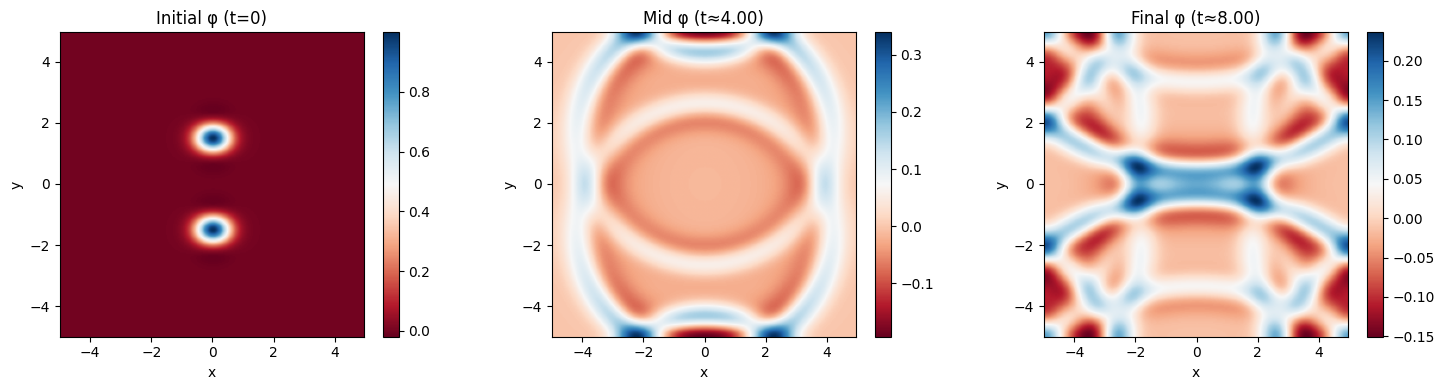

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# QFT2002b: 2D Field Interference (No Filter)
# =========================

Nx, Ny = 256, 256
Lx, Ly = 10.0, 10.0
dx, dy = Lx / Nx, Ly / Ny

dt = 0.002
n_steps = 4000
output_every = 200

c2 = 1.0
damping = 0.001

x = (np.arange(Nx) - Nx//2) * dx
y = (np.arange(Ny) - Ny//2) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

sigma = 0.4
amp = 1.0

x1, y1 = -1.5, 0.0
x2, y2 =  1.5, 0.0

p1x, p1y =  2.0, 0.0
p2x, p2y = -2.0, 0.0

def gaussian_packet(x0, y0, px, py):
    r2 = (X - x0)**2 + (Y - y0)**2
    phase = px * (X - x0) + py * (Y - y0)
    return amp * np.exp(-r2 / (2 * sigma**2)) * np.cos(phase)

def gaussian_packet_vel(x0, y0, px, py):
    r2 = (X - x0)**2 + (Y - y0)**2
    phase = px * (X - x0) + py * (Y - y0)
    omega = np.sqrt(px**2 + py**2 + 1e-12)
    return -amp * omega * np.exp(-r2 / (2 * sigma**2)) * np.sin(phase)

phi = (gaussian_packet(x1, y1, p1x, p1y) +
       gaussian_packet(x2, y2, p2x, p2y))

pi = (gaussian_packet_vel(x1, y1, p1x, p1y) +
      gaussian_packet_vel(x2, y2, p2x, p2y))

kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2

def laplacian_spectral(field):
    F = np.fft.fftn(field)
    return np.fft.ifftn(-K2 * F).real

def compute_energy(phi, pi):
    lap = laplacian_spectral(phi)
    grad2 = -phi * lap
    kinetic = 0.5 * np.sum(pi**2)
    gradient = 0.5 * np.sum(grad2)
    return kinetic + gradient

snapshots = []
times = []

print("Starting QFT2002b simulation (no filter)...")
E0 = compute_energy(phi, pi)
print(f"Initial energy: {E0:.6e}")

for step in range(n_steps):
    lap_phi = laplacian_spectral(phi)
    pi += dt * (c2 * lap_phi - damping * pi)
    phi += dt * pi

    if step % output_every == 0:
        E = compute_energy(phi, pi)
        max_phi = np.max(np.abs(phi))
        print(f"Step {step:5d} / {n_steps:5d} | E = {E:.6e} | max|phi| = {max_phi:.3e}")
        snapshots.append(phi.copy())
        times.append(step * dt)

print("QFT2002b simulation complete.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(gaussian_packet(x1, y1, p1x, p1y) +
                     gaussian_packet(x2, y2, p2x, p2y),
                     extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='RdBu')
axes[0].set_title("Initial φ (t=0)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

mid_idx = len(snapshots) // 2 if snapshots else 0
if snapshots:
    im1 = axes[1].imshow(snapshots[mid_idx],
                         extent=[x[0], x[-1], y[0], y[-1]],
                         origin='lower', cmap='RdBu')
    axes[1].set_title(f"Mid φ (t≈{times[mid_idx]:.2f})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(phi,
                     extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='RdBu')
axes[2].set_title(f"Final φ (t≈{n_steps*dt:.2f})")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()
